<a href="https://colab.research.google.com/github/alfredo170987/Proyecto-1-Sistemas-de-Comunicaci-n/blob/main/Notebook%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook 1: Autoencoders para Comunicaciones de Extremo a Extremo (Base)
El objetivo de este notebook es replicar el paper clásico de O'Shea ("An Introduction to Deep Learning for the Physical Layer"), que demostró que una red neuronal puede aprender sistemas de modulación (como BPSK o QAM) de forma autónoma.

• Entrada: Vectores de bits aleatorios (representados como vectores one-hot).

• Encoder: Capas densas (nn.Linear) que comprimen los bits en un espacio bidimensional (I/Q: En fase y cuadratura).

• Restricción de potencia: Aplicar torch.mean(x ** 2) para normalizar la constelación aprendida.

• Canal: Capa personalizada que añade ruido AWGN usando tu línea torch.randn_like.

• Decoder: Capas densas que intentan clasificar qué bits se enviaron originalmente.

• Métricas a graficar:

	• La constelación aprendida en el plano 2D (verás cómo la red agrupa los puntos de forma similar a una modulación tradicional para protegerse del ruido).
	• La curva BER vs. SNR (Tasa de error de bit frente a la relación señal-ruido).

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. HIPERPARÁMETROS DEL SISTEMA
M = 16                                                                          # Número de símbolos posibles (16-QAM)
k = int(np.log2(M))                                                             # Bits por símbolo (4 bits)
dim_canal = 2                                                                   # Dimensión del canal (2 canales: I y Q, En Fase y Cuadratura)

print(f"Sistemas de transmisión de {k} bits ({M} mensajes únicos) en un espacio de {dim_canal}D.")

# 2. DEFINICIÓN DEL AUTOENCODER DE CANAL
class AutoencoderComunicaciones(nn.Module):
    def __init__(self, M, dim_canal=2):
        super().__init__()

        # El Transmisor (Encoder) mapea el mensaje 'one-hot' al espacio del canal
        self.encoder = nn.Sequential(
            nn.Linear(M, M),
            nn.ReLU(),
            nn.Linear(M, dim_canal) # Salida: coordenadas I y Q
        )

        # El Receptor (Decoder) toma los símbolos ruidosos y clasifica el mensaje original
        self.decoder = nn.Sequential(
            nn.Linear(dim_canal, M),
            nn.ReLU(),
            nn.Linear(M, M) # Salida: Logits para clasificación (CrossEntropy)
        )

    def forward(self, x, snr_dB):
        # --- TRANSMISOR (ENCODER) ---
        x_símbolos = self.encoder(x)

        # RESTRECCIÓN DE POTENCIA (Tus fórmulas)
        # Aseguramos que la potencia promedio de los símbolos sea exactamente 1
        potencia = torch.mean(x_símbolos ** 2)
        x_tx = x_símbolos / torch.sqrt(potencia)

        # --- CANAL AWGN (Tus fórmulas) ---
        snr_lineal = 10 ** (snr_dB / 10.0)
        # Como dividimos la potencia entre dim_canal, ajustamos la varianza del ruido
        noise_var = 1.0 / (2 * dim_canal * snr_lineal)

        ruido = torch.randn_like(x_tx) * torch.sqrt(torch.tensor(noise_var))
        x_rx = x_tx + ruido

        # --- RECEPTOR (DECODER) ---
        out = self.decoder(x_rx)
        return out, x_tx

# 3. CONFIGURACIÓN DEL ENTRENAMIENTO
modelo = AutoencoderComunicaciones(M, dim_canal)
criterio = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.005)

# Generación de datos de entrenamiento (Mensajes aleatorios del 0 al M-1)
N_ENTRENAMIENTO = 50000
mensajes_entrenamiento = torch.randint(0, M, (N_ENTRENAMIENTO,))
# Convertir a vectores One-Hot para que entren a la red neuronal
x_entrenamiento = nn.functional.one_hot(mensajes_entrenamiento, num_classes=M).float()

# SNR fija para el entrenamiento (usualmente un valor medio, ej. 7 dB)
snr_entrenamiento = 10

# 4. BUCLE DE ENTRENAMIENTO
ÉPOCAS = 100
tam_lote = 1024

print("Iniciando entrenamiento del Autoencoder...")
modelo.train()
for epoca in range(ÉPOCAS):
    pérdida_total = 0
    # Mezclar datos manualmente por lotes
    permutacion = torch.randperm(x_entrenamiento.size(0))

    for i in range(0, x_entrenamiento.size(0), tam_lote):
        indices = permutacion[i:i+tam_lote]
        lote_x = x_entrenamiento[indices]
        lote_y = mensajes_entrenamiento[indices]

        optimizador.zero_grad()
        predicciones, _ = modelo(lote_x, snr_entrenamiento)

        loss = criterio(predicciones, lote_y)
        loss.backward()
        optimizador.step()

        pérdida_total += loss.item()
    if epoca % 10 == 0:
      print(f"Época {epoca}/{ÉPOCAS} - Pérdida: {pérdida_total/(N_ENTRENAMIENTO/tam_lote):.4f}")

Sistemas de transmisión de 4 bits (16 mensajes únicos) en un espacio de 2D.
Iniciando entrenamiento del Autoencoder...
Época 0/100 - Pérdida: 2.1593
Época 10/100 - Pérdida: 0.0687
Época 20/100 - Pérdida: 0.0319
Época 30/100 - Pérdida: 0.0235
Época 40/100 - Pérdida: 0.0208
Época 50/100 - Pérdida: 0.0192
Época 60/100 - Pérdida: 0.0195
Época 70/100 - Pérdida: 0.0178
Época 80/100 - Pérdida: 0.0182
Época 90/100 - Pérdida: 0.0182


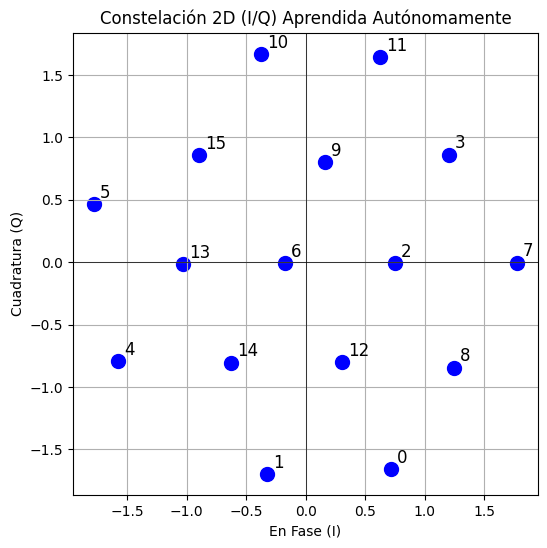

In [9]:
# Graficar la constelación generada por el Encoder
modelo.eval()
with torch.no_grad():
    identidad_m = torch.eye(M).float() # Evaluar los M mensajes posibles
    # Pasamos los mensajes por el encoder y los normalizamos
    símbolos_encoder = modelo.encoder(identidad_m)
    potencia = torch.mean(símbolos_encoder ** 2)
    constelacion = (símbolos_encoder / torch.sqrt(potencia)).numpy()

plt.figure(figsize=(6, 6))
plt.scatter(constelacion[:, 0], constelacion[:, 1], color='blue', marker='o', s=100)
for i in range(M):
    plt.text(constelacion[i, 0] + 0.05, constelacion[i, 1] + 0.05, str(i), fontsize=12)
plt.grid(True)
plt.title("Constelación 2D (I/Q) Aprendida Autónomamente")
plt.xlabel("En Fase (I)")
plt.ylabel("Cuadratura (Q)")
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.show()

Calculando Tasa de Error de Bit (BER) para diferentes niveles de SNR...
SNR: 0 dB -> BER: 0.259003
SNR: 2 dB -> BER: 0.187652
SNR: 4 dB -> BER: 0.114760
SNR: 6 dB -> BER: 0.054880
SNR: 8 dB -> BER: 0.017810
SNR: 10 dB -> BER: 0.003077
SNR: 12 dB -> BER: 0.000298
SNR: 14 dB -> BER: 0.000013


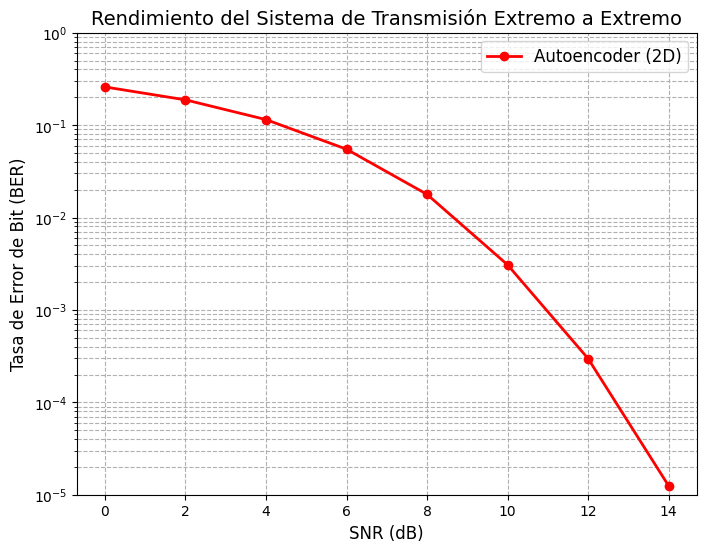

In [24]:
# 5. EVALUACIÓN DEL RENDIMIENTO: CURVA BER(Bit error rate) VS SNR
modelo.eval()

# Definir el rango de SNR (dB) a evaluar (de 0 a 14 dB)
snr_rango_dB = np.arange(0, 15, 2)
ber_resultados = []

# Función auxiliar para convertir el índice del mensaje a su representación en bits (array de ceros y unos)
def mensaje_a_bits(mensaje_id, k_bits):
    # Convierte un entero a una lista de bits de longitud fija k
    return [int(b) for b in format(mensaje_id, f'0{k_bits}b')]

# Número de mensajes de prueba por cada nivel de SNR (suficientes para medir BER bajas)
N_TEST = 100000

print("Calculando Tasa de Error de Bit (BER) para diferentes niveles de SNR...")

with torch.no_grad():
    # Generar mensajes de prueba aleatorios
    mensajes_test = torch.randint(0, M, (N_TEST,))
    x_test = nn.functional.one_hot(mensajes_test, num_classes=M).float()

    # Pre-convertir los mensajes reales a bits para comparar eficientemente
    bits_reales = np.array([mensaje_a_bits(m.item(), k) for m in mensajes_test])

    for snr_dB in snr_rango_dB:
        # Pasar los datos de prueba por el modelo con la SNR actual
        predicciones, _ = modelo(x_test, float(snr_dB))

        # El receptor elige el mensaje con el valor de logit más alto (Argmax)
        mensajes_predichos = torch.argmax(predicciones, dim=1)

        # Convertir los mensajes predichos a bits
        bits_predichos = np.array([mensaje_a_bits(m.item(), k) for m in mensajes_predichos])

        # Calcular el número total de bits erróneos
        bits_erroneos = np.sum(bits_reales != bits_predichos)
        total_bits = N_TEST * k

        # Calcular BER
        ber = bits_erroneos / total_bits
        ber_resultados.append(ber)

        print(f"SNR: {snr_dB} dB -> BER: {ber:.6f}")

# 6. GRAFICAR LA CURVA BER VS SNR
plt.figure(figsize=(8, 6))
plt.semilogy(snr_rango_dB, ber_resultados, 'ro-', linewidth=2, label='Autoencoder (2D)')
plt.grid(True, which="both", linestyle="--")
plt.xlabel('SNR (dB)', fontsize=12)
plt.ylabel('Bit Error Rate (BER)', fontsize=12)
plt.title('Rendimiento del Sistema de Transmisión Extremo a Extremo', fontsize=14)
plt.legend(fontsize=12)
plt.ylim(1e-5, 1) # Escala logarítmica estándar para BER
plt.show()



Notebook 2: Deep JSCC para Transmisión de Imágenes sobre Canales Inalámbricos

Aquí subes el nivel aplicando Codificación Conjunta de Fuente y Canal (JSCC) real. En lugar de transmitir bits, el Autoencoder aprende a transmitir características semánticas de una imagen directamente como símbolos analógicos a través del canal.

• Entrada: Dataset de imágenes pequeñas (como CIFAR-10 o MNIST).

• Encoder: Capas Convolucionales (nn.Conv2d) que reducen la dimensionalidad de la imagen (compresión de fuente) y la preparan para el canal (compresión de canal).

• Canal: Simulación de un canal inalámbrico variable (puedes empezar con AWGN y, si quieres un extra, simular un canal con desvanecimiento tipo Rayleigh).
• Decoder: Capas Convolucionales Transpuestas o Upsampling (nn.ConvTranspose2d) que reconstruyen la imagen a partir de los símbolos ruidosos recibidos.

• Función de Pérdida: Error Cuadrático Medio (MSE) entre la imagen original y la reconstruida.

• Métricas a graficar:

	• Visualización de imágenes originales vs. reconstruidas a diferentes niveles de ruido (baja SNR vs. alta SNR).
	• Curva de PSNR (Peak Signal-to-Noise Ratio) o SSIM vs. SNR del canal para demostrar el efecto de "degradación suave" (a diferencia de los sistemas tradicionales, JSCC no sufre el efecto acantilado donde la comunicación se corta de golpe al bajar la señal).

In [20]:

import torch
import torch.nn.functional as F

# Índices de clases para 3 elementos (clases 0, 2 y 1)
indices = torch.tensor([0, 2, 15, 12, 11])

# Aplicar one-hot especificando 3 clases
encoded = F.one_hot(indices, num_classes=16)
print(encoded)

arreglo = [0,1,2,3,4,5,6,7,8,9]
arreglo2 = arreglo[0:100]
print(arreglo2)

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]])
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
